<a href="https://colab.research.google.com/github/Aditi-dev07/Cisco_DataScience_Projects/blob/main/Data%20Visualization/Banknote%20dimensions/banknote-dimensions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Banknote dimensions

Which banknotes exhibit the greatest size differences between denominations? Which are the largest overall?

Banknote dimensions differ widely across countries.

The size of a banknote impacts its practicality. Uniform dimensions enhance durability by ensuring a snug wallet fit, while also enabling vending machines and ATMs to process them seamlessly. Conversely, varied sizes assist the visually impaired in distinguishing denominations, though smaller notes can pose challenges for machine sorting and counting.

Striking a balance between these considerations is essential in currency design.

The file `banknote-dimensions.csv` shows the `length` and `width` in millimeters for 42 currencies. This dataset spans all 22 subregions and sub-subregions of the world, as defined by the United Nations Statistics Division's geoscheme.

In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'banknote-dimensions.csv'.

from google.colab import files
uploaded = files.upload()

Saving banknote-dimensions.csv to banknote-dimensions.csv


In [63]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('banknote-dimensions.csv')
df

,currency,code,value,length,width
0,Argentine Peso,ARS,2,155.0,65.0
1,Argentine Peso,ARS,5,155.0,65.0
2,Argentine Peso,ARS,10,155.0,65.0
3,Argentine Peso,ARS,20,155.0,65.0
4,Argentine Peso,ARS,50,155.0,65.0
...,...,...,...,...,...
245,West African Franc,XOF,500,114.0,60.0
246,West African Franc,XOF,1000,125.0,66.0
247,West African Franc,XOF,2000,130.0,65.0
248,West African Franc,XOF,5000,140.0,74.0


# longest and shortest banknotes for each currency

In [64]:
# longest and shortest banknotes for each currency
# modify the code below if you are more interested in width
length = df.groupby('currency').agg(max=('length', 'max'), min=('length', 'min')).reset_index()
length['diff'] = length['max'] - length['min']
length.head()

,currency,max,min,diff
0,Argentine Peso,155.0,155.0,0.0
1,Australian Dollar,158.0,130.0,28.0
2,Bangladeshi Taka,155.0,100.0,55.0
3,Bolivian Boliviano,140.0,140.0,0.0
4,Canadian Dollar,152.4,152.4,0.0


In [65]:
# helper function, change gap, vertical alignment, horizontal alignment, placement of gap...
def add_labels(df, x_col, y_col, label_col):
	for i, row in df.iterrows():
		x = row[x_col]
		y = row[y_col]
		gap = "  "
		label = gap + row[label_col]
		plt.text(x, y, label, va='center', ha='left')

### Project Ideas

- Generate paired scatter plots to compare the `length` of the longest and shortest banknotes for each currency.

- Create similar paired scatter plots, but for `width` instead of `length`.

- Incorporate the Pro Tips into your visualizations.

- Add labels to data points to highlight key insights or narrate a compelling story.

- Calculate the percentage of currencies where:
	- Only the `length` remains consistent across all denominations.
	- Only the `width` remains consistent across all denominations.
	- Both `length` and `width` vary with denominations.
	- All denominations share identical `length` and `width` dimensions.

- Visualize these findings in a clear, engaging format.

Below is a preliminary paired scatter plot of banknote length to serve as a starting point.

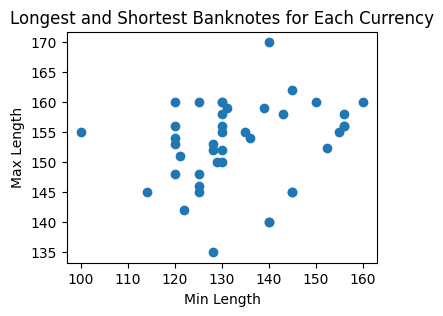

In [66]:
plt.figure(figsize=(4, 3))
plt.scatter(length['min'], length['max'])
plt.xlabel('Min Length')
plt.ylabel('Max Length')
plt.title('Longest and Shortest Banknotes for Each Currency')
plt.show()

##Create similar paired scatter plots, but for width instead of length.

In [67]:
width = df.groupby('currency').agg(max=('width', 'max'), min=('width', 'min')).reset_index()
width['diff'] = width['max'] - width['min']
width.head()

,currency,max,min,diff
0,Argentine Peso,65.00,65.00,0.0
1,Australian Dollar,72.50,65.00,7.5
2,Bangladeshi Taka,65.00,60.00,5.0
3,Bolivian Boliviano,70.00,70.00,0.0
4,Canadian Dollar,69.85,69.85,0.0


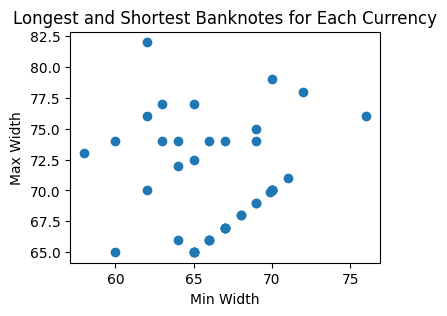

In [68]:
plt.figure(figsize=(4, 3))
plt.scatter(width['min'], width['max'])
plt.xlabel('Min Width')
plt.ylabel('Max Width')
plt.title('Longest and Shortest Banknotes for Each Currency')
plt.show()

##Incorporate the Pro Tips into your visualizations.

###Add labels to data points to highlight key insights or narrate a compelling story.

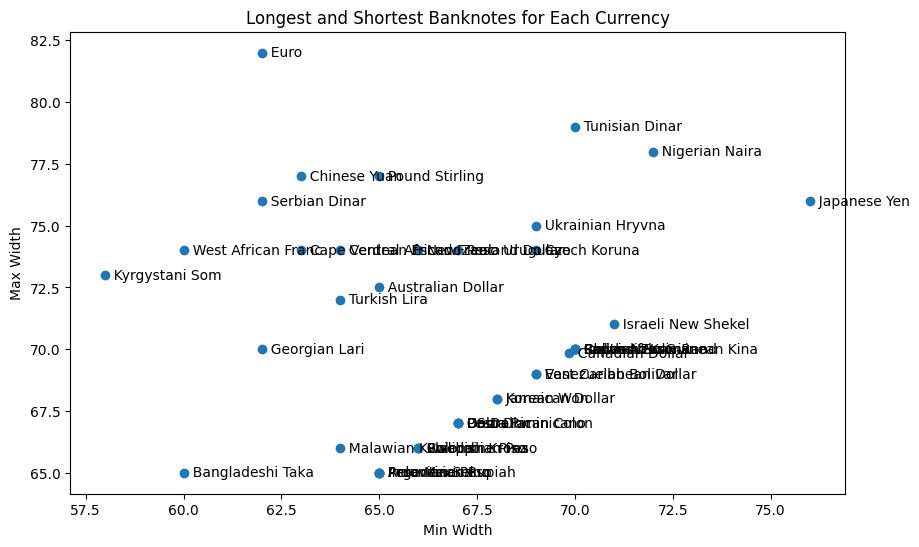

In [69]:
plt.figure(figsize=(10, 6))
plt.scatter(width['min'], width['max'])
plt.xlabel('Min Width')
plt.ylabel('Max Width')
plt.title('Longest and Shortest Banknotes for Each Currency')
add_labels(width, 'min', 'max', 'currency')
plt.show()


##Calculate the percentage of currencies where:

###Only the length remains consistent across all denominations.

In [70]:
length = df.groupby('currency').agg(max=('length', 'max'), min=('length', 'min')).reset_index()
length['diff'] = length['max'] - length['min']
length.head()

,currency,max,min,diff
0,Argentine Peso,155.0,155.0,0.0
1,Australian Dollar,158.0,130.0,28.0
2,Bangladeshi Taka,155.0,100.0,55.0
3,Bolivian Boliviano,140.0,140.0,0.0
4,Canadian Dollar,152.4,152.4,0.0


In [71]:
# Count total number of currencies
total_currencies = length.shape[0]

consistent_length = (length['diff'] == 0).sum()

# Calculate percentage
percentage_l = (consistent_length / total_currencies) * 100

print(f"Percentage of currencies where only length remains consistent: {percentage:.2f}%")

Percentage of currencies where only length remains consistent: 54.76%


##Only the width remains consistent across all denominations.

In [72]:
width = df.groupby('currency').agg(max=('width', 'max'), min=('width', 'min')).reset_index()
width['diff'] = width['max'] - width['min']
width.head()

,currency,max,min,diff
0,Argentine Peso,65.00,65.00,0.0
1,Australian Dollar,72.50,65.00,7.5
2,Bangladeshi Taka,65.00,60.00,5.0
3,Bolivian Boliviano,70.00,70.00,0.0
4,Canadian Dollar,69.85,69.85,0.0


In [56]:
total_currencies = width.shape[0]

consistent_width = (width['diff'] == 0).sum()

# Calculate percentage
percentage = (consistent_width / total_currencies) * 100

print(f"Percentage of currencies where only width remains consistent: {percentage:.2f}%")

Percentage of currencies where only width remains consistent: 54.76%


##Both length and width vary with denominations.

In [73]:
merge = pd.merge ( length, width, on='currency', suffixes = ('_length', '_width'))
merge.head()

,currency,max_length,min_length,diff_length,max_width,min_width,diff_width
0,Argentine Peso,155.0,155.0,0.0,65.00,65.00,0.0
1,Australian Dollar,158.0,130.0,28.0,72.50,65.00,7.5
2,Bangladeshi Taka,155.0,100.0,55.0,65.00,60.00,5.0
3,Bolivian Boliviano,140.0,140.0,0.0,70.00,70.00,0.0
4,Canadian Dollar,152.4,152.4,0.0,69.85,69.85,0.0


In [74]:
both_vary = len(merge[(merge['diff_length'] != 0.0) & (merge['diff_width'] != 0.0)])
percent_v = (both_vary/ total_currencies)*100
print(f'vary:{percent:.2f}')

vary:45.24


##All denominations share identical length and width dimensions.

In [75]:
identical = len(merge[(merge['diff_length'] == 0.0) & (merge['diff_width'] == 0.0)])
percent_i = (identical/ total_currencies)*100
print(f'identical:{percent:.2f}')

identical:45.24


##Visualize these findings in a clear, engaging format.

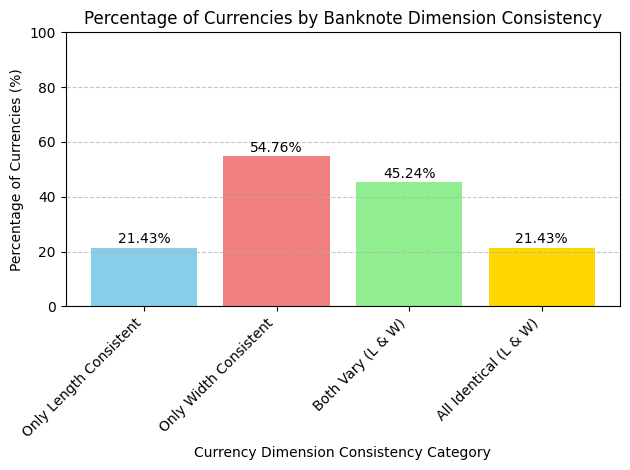

In [76]:

x = ['Only Length Consistent', 'Only Width Consistent', 'Both Vary (L & W)', 'All Identical (L & W)']
y = [percentage_l, percentage, percent_v, percent_i] # Using the correct calculated percentages

plt.bar(x, y, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.xlabel('Currency Dimension Consistency Category')
plt.ylabel('Percentage of Currencies (%)')
plt.title('Percentage of Currencies by Banknote Dimension Consistency')
plt.ylim(0, 100) # Set y-axis limit from 0 to 100 for percentages
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
for index, value in enumerate(y):
    plt.text(x[index], value + 0.5, f'{value:.2f}%', ha='center', va='bottom')
plt.tight_layout()
plt.show()